In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
% pip install -q ultralytics lxml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.6 MB/s eta 0:00:00


In [ ]:
import os
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
DATASET = "/content/drive/MyDrive/classification"

In [ ]:
print(DATASET)

/content/drive/MyDrive/classification


In [ ]:
expected = [
    "train/images",
    "train/annos",
    "val/images",
    "val/annos",
    "test/images",
    "test/annos"
]

print("="*50)

for folder in expected:
    path = os.path.join(DATASET, folder)

    if os.path.exists(path):
        print("✓", folder)
    else:
        print("✗ Missing:", folder)

✓ train/images
✓ train/annos
✓ val/images
✓ val/annos
✓ test/images
✓ test/annos


In [ ]:
for split in ["train","val","test"]:

    img_dir = os.path.join(DATASET, split, "images")
    xml_dir = os.path.join(DATASET, split, "annos")

    imgs = [f for f in os.listdir(img_dir)
            if f.lower().endswith((".jpg",".jpeg",".png"))]

    xmls = [f for f in os.listdir(xml_dir)
            if f.endswith(".xml")]

    print("="*40)
    print(split.upper())
    print("Images :", len(imgs))
    print("XMLs   :", len(xmls))

TRAIN
Images : 3535
XMLs   : 3535
VAL
Images : 884
XMLs   : 884
TEST
Images : 1083
XMLs   : 1083


In [ ]:
for split in ["train","val","test"]:

    img_dir = Path(DATASET)/split/"images"
    xml_dir = Path(DATASET)/split/"annos"

    images = {p.stem for p in img_dir.glob("*")}
    xmls = {p.stem for p in xml_dir.glob("*.xml")}

    missing_xml = images - xmls
    missing_img = xmls - images

    print("="*60)
    print(split)

    print("Images without XML :", len(missing_xml))
    print("XML without Image :", len(missing_img))

    if missing_xml:
        print(list(sorted(missing_xml))[:10])

    if missing_img:
        print(list(sorted(missing_img))[:10])

train
Images without XML : 0
XML without Image : 0
val
Images without XML : 0
XML without Image : 0
test
Images without XML : 0
XML without Image : 0


In [ ]:
for split in ["train","val","test"]:

    img_dir = Path(DATASET)/split/"images"
    xml_dir = Path(DATASET)/split/"annos"

    images = {p.stem:p for p in img_dir.glob("*")}
    xmls = {p.stem:p for p in xml_dir.glob("*.xml")}

    for stem,path in images.items():
        if stem not in xmls:
            print("Removing image:", path.name)
            path.unlink()

    for stem,path in xmls.items():
        if stem not in images:
            print("Removing xml:", path.name)
            path.unlink()

In [ ]:
for split in ["train","val","test"]:

    labels = os.path.join(DATASET, split, "labels")

    os.makedirs(labels, exist_ok=True)

In [ ]:
CLASS_MAP = {

    "motorcycle":"motorcycle",
    "bike":"motorcycle",

    "scooter":"scooter",

    "car":"car",

    "bus":"bus",

    "truck":"truck",

    "bicycle":"bicycle",

    "cycle":"bicycle",

    "auto":"auto_rickshaw",
    "autorickshaw":"auto_rickshaw",
    "auto_rickshaw":"auto_rickshaw",

    "van":"van",

    "pickup":"pickup"
}

In [ ]:
CLASSES = sorted(set(CLASS_MAP.values()))

CLASS_TO_ID = {c:i for i,c in enumerate(CLASSES)}

print(CLASS_TO_ID)

{'auto_rickshaw': 0, 'bicycle': 1, 'bus': 2, 'car': 3, 'motorcycle': 4, 'pickup': 5, 'scooter': 6, 'truck': 7, 'van': 8}


In [ ]:
def convert_box(size, box):

    dw = 1./size[0]
    dh = 1./size[1]

    xmin,xmax,ymin,ymax = box

    x = (xmin+xmax)/2.0
    y = (ymin+ymax)/2.0

    w = xmax-xmin
    h = ymax-ymin

    return x*dw,y*dh,w*dw,h*dh


generated = {}

for split in ["train","val","test"]:

    generated[split]=0

    xml_dir = Path(DATASET)/split/"annos"
    label_dir = Path(DATASET)/split/"labels"

    for xml_file in xml_dir.glob("*.xml"):

        tree = ET.parse(xml_file)
        root = tree.getroot()

        size = root.find("size")

        width = int(size.find("width").text)
        height = int(size.find("height").text)

        lines=[]

        for obj in root.findall("object"):

            original = obj.find("name").text.strip()

            base = original.split("_")[0].lower()

            if base not in CLASS_MAP:
                continue

            cls = CLASS_MAP[base]

            cls_id = CLASS_TO_ID[cls]

            b = obj.find("bndbox")

            xmin=float(b.find("xmin").text)
            xmax=float(b.find("xmax").text)
            ymin=float(b.find("ymin").text)
            ymax=float(b.find("ymax").text)

            bb = convert_box((width,height),(xmin,xmax,ymin,ymax))

            lines.append(
                f"{cls_id} {' '.join(f'{v:.6f}' for v in bb)}"
            )

        with open(label_dir/(xml_file.stem+".txt"),"w") as f:
            f.write("\n".join(lines))

        generated[split]+=1

print(generated)


KeyboardInterrupt: 

In [ ]:
for split in ["train","val","test"]:

    images = len(list((Path(DATASET)/split/"images").glob("*")))
    labels = len(list((Path(DATASET)/split/"labels").glob("*.txt")))

    print("="*40)
    print(split)

    print("Images:",images)
    print("Labels:",labels)

train
Images: 3535
Labels: 3535
val
Images: 884
Labels: 884
test
Images: 1083
Labels: 1083


In [ ]:
yaml_text = f"""
path: {DATASET}

train: train/images
val: val/images
test: test/images

names:
"""

for i,c in enumerate(CLASSES):
    yaml_text += f"  {i}: {c}\n"

yaml_path = os.path.join(DATASET,"data.yaml")

with open(yaml_path,"w") as f:
    f.write(yaml_text)

print(yaml_text)


path: /content/drive/MyDrive/classification

train: train/images
val: val/images
test: test/images

names:
  0: auto_rickshaw
  1: bicycle
  2: bus
  3: car
  4: motorcycle
  5: pickup
  6: scooter
  7: truck
  8: van



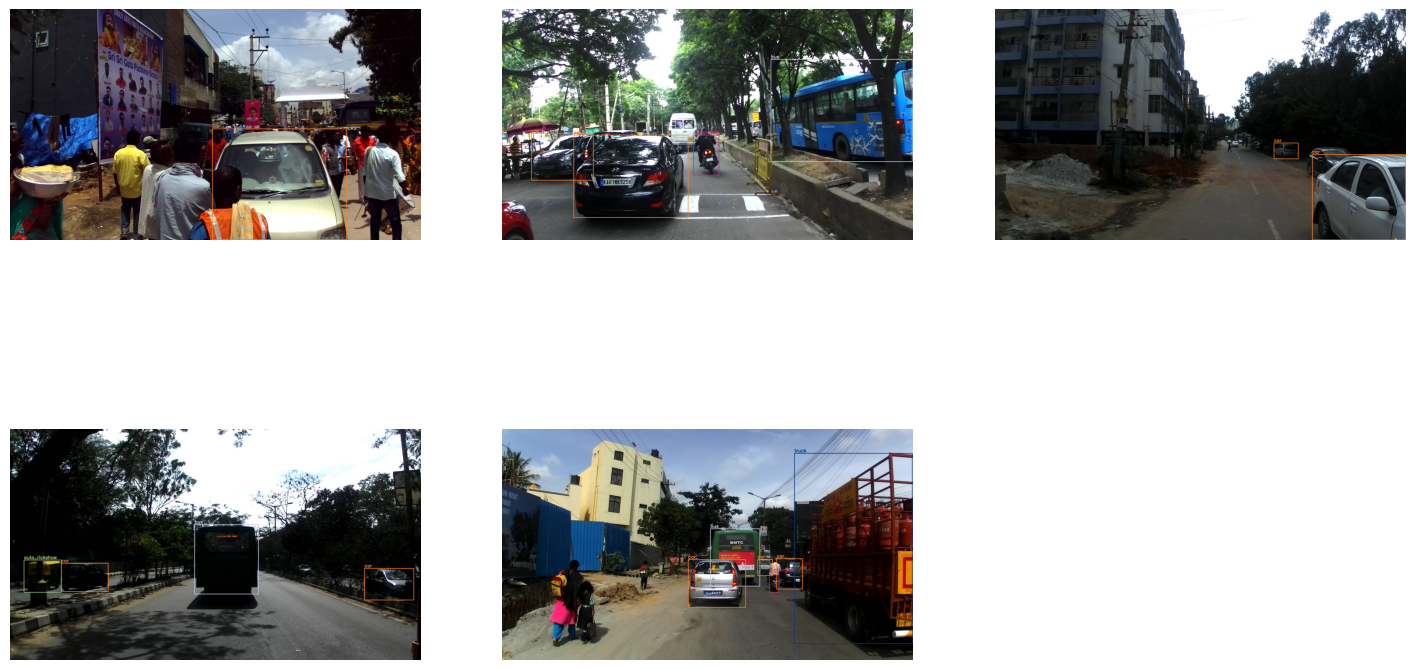

In [ ]:
colors={i:(random.randint(0,255),
           random.randint(0,255),
           random.randint(0,255))
        for i in range(len(CLASSES))}

imgs=list((Path(DATASET)/"train"/"images").glob("*"))

sample=random.sample(imgs,5)

plt.figure(figsize=(18,10))

for i,img_path in enumerate(sample):

    img=cv2.imread(str(img_path))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    h,w,_=img.shape

    label=Path(DATASET)/"train"/"labels"/(img_path.stem+".txt")

    if label.exists():

        for line in open(label):

            cls,x,y,bw,bh=map(float,line.split())

            cls=int(cls)

            x1=int((x-bw/2)*w)
            y1=int((y-bh/2)*h)
            x2=int((x+bw/2)*w)
            y2=int((y+bh/2)*h)

            cv2.rectangle(img,(x1,y1),(x2,y2),colors[cls],2)

            cv2.putText(img,
                        CLASSES[cls],
                        (x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        colors[cls],
                        2)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    workers=2,
    project="/content/drive/MyDrive/yolo_training",
    name="vehicle_detector"
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/classification/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detector-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 2, 3, 4, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5084c80ce0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_training/vehicle_detector/weights/best.pt")

metrics = model.val()

print(metrics)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 146.9±42.4 MB/s, size: 467.4 KB)
val: Scanning /content/drive/MyDrive/classification/val/labels.cache... 884 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 884/884 309.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 2.5it/s 22.3s
                   all        884       3798      0.837       0.79       0.87      0.701
         auto_rickshaw        371        610      0.853      0.848      0.915      0.799
                   bus        158        199      0.826      0.734      0.819       0.69
                   car        618       1278      0.861      0.848      0.921      0.788
            motorcycle        474        780       0.77        0.8      0.838      0.603
               scooter       

In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_training/vehicle_detector/weights/best.pt")

results = model.predict(
    source=f"{DATASET}/test/images",
    save=True,
    conf=0.25
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1083 /content/drive/MyDrive/classification/test/images/4810.jpg: 384x640 1 car, 4 motorcycles, 2 scooters, 39.5ms
image 2/1083 /content/drive/MyDrive/classification/test/images/4811.jpg: 384x640 1 auto_rickshaw, 1 car, 2 motorcycles, 1 truck, 8.6ms
image 3/1083 /content/drive/MyDrive/classification/test/images/4812.jpg: 384x640 3 auto_rickshaws, 3 cars, 1 motorcycle, 2 scooters, 6.2ms
image 4/1083 /content/drive/MyDrive/classification/test/images

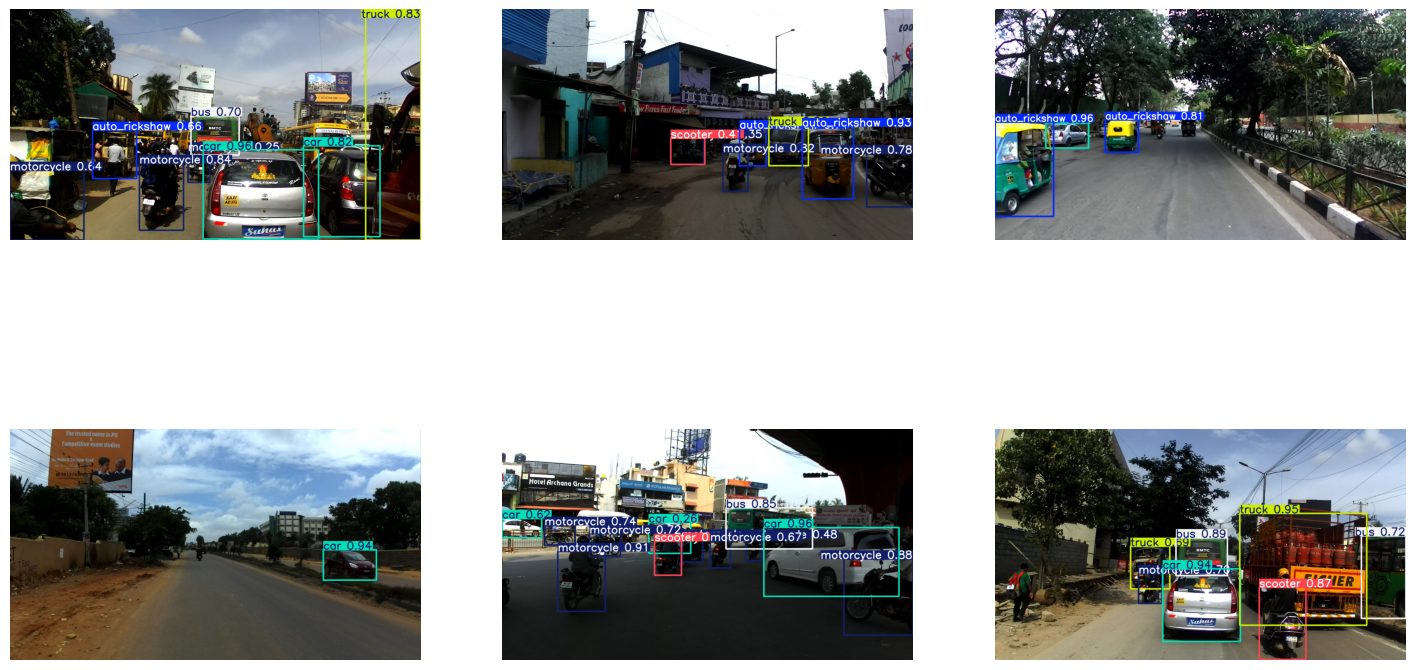

In [ ]:
from glob import glob

preds = glob("runs/detect/predict/*.jpg")

plt.figure(figsize=(18,10))

for i,p in enumerate(preds[:6]):

    img=cv2.imread(p)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
best = "/content/drive/MyDrive/yolo_training/vehicle_detector/weights/best.pt"

if os.path.exists(best):
    print("Training completed successfully.")
    print(best)
else:
    print("best.pt not found.")

Training completed successfully.
/content/drive/MyDrive/yolo_training/vehicle_detector/weights/best.pt
